[nltk_data] Downloading package punkt to C:\Users\sweeny
[nltk_data]     rodrigues\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\sweeny
[nltk_data]     rodrigues\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to C:\Users\sweeny
[nltk_data]     rodrigues\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


✅ Extracted Text:

Paper is a crucial tool in education. It’s
a thin material made from trees. People
write, draw, or print on it. It’s used in
exams, homework, and notes. Paper
comes in various sizes and types, like
plain or lined. It's lightweight and easy
to carry. We use it in everyday life, from
reading newspapers to writing letters.
Without paper, learning and
communication would be challenging.
It's affordable and accessible, making it
indispensable. Despite advancements in
technology, paper remains an essential
part of our lives. It symbolizes
knowledge, creativity, and expression.

(Gaspirantsessay.com

📖 Summary:
Paper is a crucial tool in education. It’s
a thin material made from trees. People
write, draw, or print on it. It’s used in
exams, homework, and notes.

😊 Sentiment Analysis:
Sentiment: Positive (Score: 0.8225)

🔑 Keywords:
[('paper', 4), ('crucial', 1), ('tool', 1), ('education', 1), ('thin', 1), ('material', 1)]


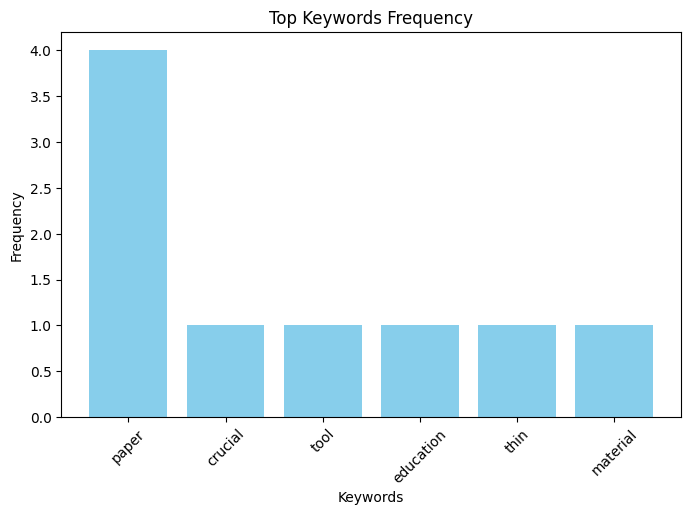


👤 Named Entities:
[('Gaspirantsessay.com', 'ORG')]

✨ Golden Lines:
💡 Paper
comes in various sizes and types, like
plain or lined.
💡 Despite advancements in
technology, paper remains an essential
part of our lives.
💡 We use it in everyday life, from
reading newspapers to writing letters.


In [9]:
# 📌 Import Libraries
import nltk
import matplotlib.pyplot as plt
from collections import Counter
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
import spacy
from PIL import Image
import pytesseract

# 📌 Configure Tesseract (update path if needed)
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

# 📌 Download NLTK Resources (only once)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')

# 📌 Load SpaCy Model
try:
    nlp = spacy.load("en_core_web_sm")
except:
    nlp = spacy.blank("en")

#========== FUNCTIONS ==========#

# Summarization
def summarize_text(text, summary_type="medium"):
    sentences = sent_tokenize(text)
    if not sentences:
        return "No text available for summary."
    if summary_type == "short":
        return " ".join(sentences[:2])
    elif summary_type == "medium":
        return " ".join(sentences[:4])
    elif summary_type == "bullet":
        return "\n- " + "\n- ".join(sentences[:5])

# Sentiment Analysis
def analyze_sentiment(text):
    sia = SentimentIntensityAnalyzer()
    score = sia.polarity_scores(text)
    if score['compound'] >= 0.05:
        sentiment = "Positive"
    elif score['compound'] <= -0.05:
        sentiment = "Negative"
    else:
        sentiment = "Neutral"
    return sentiment, score['compound']

# Keyword Extraction
def extract_keywords(text, top_n=10):
    words = word_tokenize(text.lower())
    stop_words = set(stopwords.words('english'))
    filtered_words = [w for w in words if w.isalnum() and w not in stop_words]
    freq = Counter(filtered_words)
    return freq.most_common(top_n)

# Named Entity Recognition
def extract_entities(text):
    doc = nlp(text)
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    return entities

# Keyword Frequency Chart
def plot_keyword_chart(keywords):
    if not keywords:
        return
    words, counts = zip(*keywords)
    plt.figure(figsize=(8,5))
    plt.bar(words, counts, color="skyblue")
    plt.title("Top Keywords Frequency")
    plt.xlabel("Keywords")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)
    plt.show()

# Golden Lines Extraction
def extract_golden_lines(text, top_n=3):
    sentences = sent_tokenize(text)
    if not sentences:
        return []
    words = word_tokenize(text.lower())
    stop_words = set(stopwords.words('english'))
    keywords = [w for w in words if w.isalnum() and w not in stop_words]

    scored_sentences = []
    for sent in sentences:
        score = sum([1 for w in word_tokenize(sent.lower()) if w in keywords])
        scored_sentences.append((sent, score))

    scored_sentences.sort(key=lambda x: x[1], reverse=True)
    return [sent for sent, score in scored_sentences[:top_n]]

# OCR Function for Images
def extract_text_from_image(image_file):
    img = Image.open(image_file)
    text = pytesseract.image_to_string(img)
    return text

image_path = r"C:\Users\sweeny rodrigues\Downloads\Paragraph-on-Paper.png"

# Call function with your image path
text = extract_text_from_image(image_path)

print("✅ Extracted Text:\n")
print(text)

#========== USAGE EXAMPLE ==========#

# Example text
text1 = """
"""

print("📖 Summary:")
print(summarize_text(text, "medium"))

print("\n😊 Sentiment Analysis:")
sentiment, score = analyze_sentiment(text)
print(f"Sentiment: {sentiment} (Score: {score})")

print("\n🔑 Keywords:")
keywords = extract_keywords(text, 6)
print(keywords)
plot_keyword_chart(keywords)

print("\n👤 Named Entities:")
entities = extract_entities(text)
print(entities if entities else "No entities found")

print("\n✨ Golden Lines:")
golden_lines = extract_golden_lines(text)
for line in golden_lines:
    print(f"💡 {line}")       
